# The images behind one well

{func}`~mantispy.ds.jump_plate` returns two fields of view of well `O09` of `BR00121438` {cite:p}`Chandrasekaran_2023` as a `SpatialData` object: the eight channel images of each field, the CellProfiler outlines they were segmented with, and the plate's cells table. The cells measured from these fields are in {func}`~mantispy.ds.jump_cells`, and the well-level profiles of the same plate in {func}`~mantispy.ds.jump_target2`. It needs the spatial extra.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mantispy as mt

In [2]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sdata = mt.ds.jump_plate()
sdata

SpatialData object
├── Images
│     ├── 'BR00121438_O09_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     └── 'BR00121438_O09_s2_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
├── Labels
│     ├── 'BR00121438_O09_s1_cells': DataArray[yx] (1080, 1080)
│     ├── 'BR00121438_O09_s1_cytoplasm': DataArray[yx] (1080, 1080)
│     ├── 'BR00121438_O09_s1_nuclei': DataArray[yx] (1080, 1080)
│     ├── 'BR00121438_O09_s2_cells': DataArray[yx] (1080, 1080)
│     ├── 'BR00121438_O09_s2_cytoplasm': DataArray[yx] (1080, 1080)
│     └── 'BR00121438_O09_s2_nuclei': DataArray[yx] (1080, 1080)
└── Tables
      └── 'cells': AnnData (284, 1989)
with coordinate systems:
    ▸ 'BR00121438', with elements:
        BR00121438_O09_s1_image (Images), BR00121438_O09_s2_image (Images), BR00121438_O09_s1_cells (Labels), BR00121438_O09_s1_cytoplasm (Labels), BR00121438_O09_s1_nuclei (Labels), BR00121438_O09_s2_cells (Labels), BR00121438_O09_s2_cytoplasm (Labels), BR0012

## The five fluorescence channels

The eight acquisition channels include three brightfield planes; the five Cell Painting fluorescence channels are DNA, the endoplasmic reticulum (ER), RNA, the mitochondria (Mito) and the actin, Golgi and plasma membrane stain (AGP). Each is clipped to its 1st and 99th percentiles for display.

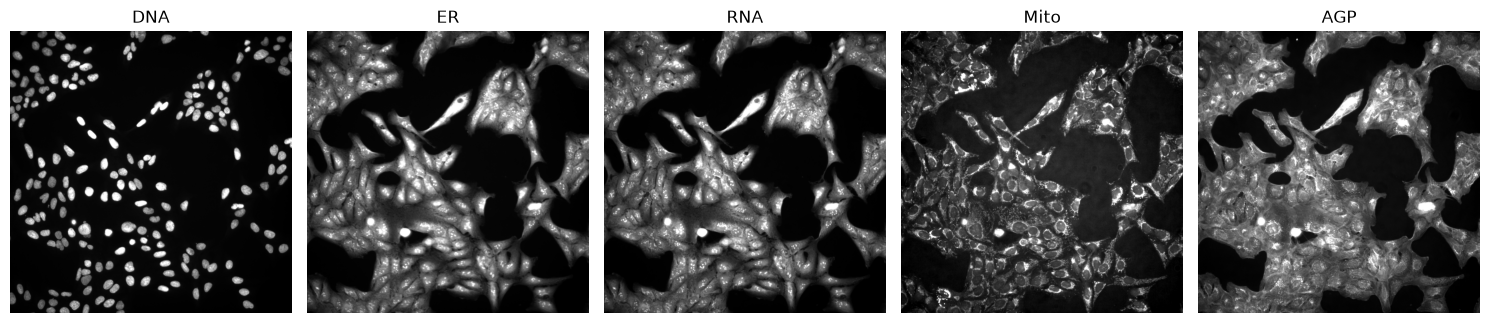

In [3]:
image = sdata.images["BR00121438_O09_s1_image"]["scale0"]["image"]
channels = ["DNA", "ER", "RNA", "Mito", "AGP"]
fig, axes = plt.subplots(1, len(channels), figsize=(15, 3.2))
for ax, channel in zip(axes, channels, strict=True):
    plane = np.asarray(image.sel(c=channel).data)
    low, high = np.percentile(plane, [1, 99])
    ax.imshow(plane, cmap="gray", vmin=low, vmax=high)
    ax.set_title(channel)
    ax.axis("off")
fig.tight_layout()